In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Assam 2023 — Generalization Test (Kaggle)

**Datasets:**
- `assam-flood-2023-tiles` → `/kaggle/input/assam-flood-2023-tiles/`
- `flood-model-checkpoints` → `/kaggle/input/flood-model-checkpoints/`

**Channel order:** VV(0),VH(1),B2(2),B3(3),B4(4),B8(5),B11(6),B12(7),Elev(8),Slope(9),TWI(10),HAND(11),NDWI(12),NDVI(13)

In [1]:
!pip install -q rasterio
!apt-get install -q gdal-bin python3-gdal

import numpy as np
import rasterio
from rasterio.windows import Window
from osgeo import gdal
import torch
import torch.nn as nn
import torch.nn.functional as F
import json, gc, os, shutil, warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-dev python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 138 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 8s (637 kB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 120314 files and directories currently 

In [2]:
TILES_DIR     = '/kaggle/input/assam-flood-2023-tiles/assam-flood-2023-tiles/assam-flood-2023-tiles'
SAR_LABEL_DIR = '/kaggle/input/assam-flood-2023-tiles'
MODELS_DIR    = '/kaggle/input/datasets/majorproject777/flood-model-checkpoints/flood-model-checkpoints'
LOCAL_BASE    = '/kaggle/working/assam2023'
os.makedirs(LOCAL_BASE, exist_ok=True)

VARIANT1_CKPT = f'{MODELS_DIR}/temporal_mlp_best_model.pth'
VARIANT5_CKPT = f'{MODELS_DIR}/spatial_best_model.pth'
NORM_STATS    = f'{MODELS_DIR}/norm_stats.json'
out_v1 = f'{LOCAL_BASE}/assam_pred_v1.tif'
out_v5 = f'{LOCAL_BASE}/assam_pred_v5.tif'

# Verify
for name, path in [
    ('V1 checkpoint',  VARIANT1_CKPT),
    ('V5 checkpoint',  VARIANT5_CKPT),
    ('Norm stats',     NORM_STATS),
    ('Tiles dir',      TILES_DIR),
]:
    status = '✅' if os.path.exists(path) else '❌ MISSING'
    print(f'{status}  {name}')

# Resume check
resume_v1 = f'{TILES_DIR}/assam_pred_v1.tif'
resume_v5 = f'{TILES_DIR}/assam_pred_v5.tif'
RESUMING = os.path.exists(resume_v1) and os.path.exists(resume_v5)
print(f'\nResume from previous run: {RESUMING}')
if RESUMING:
    import shutil
    shutil.copy2(resume_v1, out_v1)
    shutil.copy2(resume_v5, out_v5)
    print('Copied ✅')

✅  V1 checkpoint
✅  V5 checkpoint
✅  Norm stats
✅  Tiles dir

Resume from previous run: True
Copied ✅


In [4]:
HAND_CHANNEL = 11

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        return self.conv(torch.cat([self.up(x), skip], dim=1))

class UNet(nn.Module):
    def __init__(self, in_channels=14):
        super().__init__()
        f = 64
        self.enc1       = ConvBlock(in_channels, f)
        self.enc2       = Down(f,    f*2)
        self.enc3       = Down(f*2,  f*4)
        self.enc4       = Down(f*4,  f*8)
        self.bottleneck = Down(f*8,  f*16)
        self.dec4       = Up(f*16, f*8,  f*8)
        self.dec3       = Up(f*8,  f*4,  f*4)
        self.dec2       = Up(f*4,  f*2,  f*2)
        self.dec1       = Up(f*2,  f,    f)
        self.out        = nn.Conv2d(f, 1, 1)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(e1); e3 = self.enc3(e2)
        e4 = self.enc4(e3); b  = self.bottleneck(e4)
        d4 = self.dec4(b,e4); d3 = self.dec3(d4,e3)
        d2 = self.dec2(d3,e2); d1 = self.dec1(d2,e1)
        return self.out(d1)

class TerrainConditionedTemporalMLP(nn.Module):
    def __init__(self, n_features, hidden_size, out_channels, bottleneck_size=32):
        super().__init__()
        self.bottleneck_size = bottleneck_size
        self.mlp = nn.Sequential(
            nn.Linear(n_features, hidden_size), nn.ReLU(inplace=True), nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(inplace=True),
            nn.Linear(hidden_size, out_channels),
        )
        self.hand_gate = nn.Sequential(nn.Conv2d(1, out_channels, 1, bias=True), nn.Sigmoid())
        self.hand_pool = nn.AdaptiveAvgPool2d((bottleneck_size, bottleneck_size))
    def forward(self, temp_feats, spatial):
        t    = self.mlp(temp_feats).unsqueeze(-1).unsqueeze(-1)
        t    = t.expand(-1, -1, self.bottleneck_size, self.bottleneck_size)
        hand = spatial[:, HAND_CHANNEL:HAND_CHANNEL+1, :, :]
        gate = self.hand_gate(self.hand_pool(hand))
        return t * gate

class UNetTemporalMLP(nn.Module):
    def __init__(self, spatial_channels=14, n_temporal_feats=5, mlp_hidden=128, base_features=64):
        super().__init__()
        f = base_features
        self.enc1    = ConvBlock(spatial_channels, f)
        self.enc2    = Down(f, f*2); self.enc3 = Down(f*2, f*4); self.enc4 = Down(f*4, f*8)
        self.down_bn = nn.MaxPool2d(2)
        self.temporal_mlp = TerrainConditionedTemporalMLP(n_temporal_feats, mlp_hidden, f*8, 32)
        self.fusion_conv  = nn.Sequential(nn.Conv2d(f*8+f*8, f*8, 1, bias=False), nn.BatchNorm2d(f*8), nn.ReLU(inplace=True))
        self.bottleneck   = ConvBlock(f*8, f*16)
        self.dec4 = Up(f*16, f*8, f*8); self.dec3 = Up(f*8, f*4, f*4)
        self.dec2 = Up(f*4, f*2, f*2);  self.dec1 = Up(f*2, f,   f)
        self.head = nn.Conv2d(f, 1, 1)
    def forward(self, spatial, temp_feats):
        e1=self.enc1(spatial); e2=self.enc2(e1); e3=self.enc3(e2); e4=self.enc4(e3)
        s_bn=self.down_bn(e4)
        t_feat=self.temporal_mlp(temp_feats, spatial)
        fused=self.fusion_conv(torch.cat([s_bn, t_feat], dim=1))
        bn=self.bottleneck(fused)
        d4=self.dec4(bn,e4); d3=self.dec3(d4,e3); d2=self.dec2(d3,e2); d1=self.dec1(d2,e1)
        return self.head(d1)

print('Model classes defined ✅')

Model classes defined ✅


In [5]:
model_v1 = UNet(in_channels=14).to(DEVICE)
model_v1.load_state_dict(torch.load(VARIANT1_CKPT, map_location=DEVICE))
model_v1.eval()
print('Variant 1 loaded ✅')

model_v5 = UNetTemporalMLP().to(DEVICE)
model_v5.load_state_dict(torch.load(VARIANT5_CKPT, map_location=DEVICE))
model_v5.eval()
print('Variant 5 loaded ✅')

Variant 1 loaded ✅
Variant 5 loaded ✅


In [6]:
def build_vrt(pattern, out_vrt, search_dir=None):
    d = search_dir if search_dir else TILES_DIR
    tiles = sorted([f'{d}/{f}' for f in os.listdir(d)
                    if pattern in f and f.endswith('.tif')])
    print(f'{pattern}: {len(tiles)} tiles')
    gdal.BuildVRT(out_vrt, tiles)
    with rasterio.open(out_vrt) as src:
        print(f'  → {src.height}×{src.width}, {src.count} bands')
    return out_vrt

vrt_s1f   = build_vrt('S1_flood',       f'{LOCAL_BASE}/S1_flood.vrt')
vrt_s2    = build_vrt('assam2023_S2',   f'{LOCAL_BASE}/S2.vrt')
vrt_dem   = build_vrt('assam2023_DEM',  f'{LOCAL_BASE}/DEM.vrt')
vrt_label = build_vrt('sar_label_final', f'{LOCAL_BASE}/sar_label.vrt',
                       search_dir=SAR_LABEL_DIR)  # ← only this one!

with rasterio.open(vrt_s1f) as src:
    MOSAIC_H=src.height; MOSAIC_W=src.width
    meta=src.meta.copy(); transform=src.transform; crs=src.crs
print(f'Mosaic: {MOSAIC_H}×{MOSAIC_W}')

S1_flood: 8 tiles
  → 42777×70422, 2 bands
assam2023_S2: 12 tiles
  → 42777×70422, 6 bands
assam2023_DEM: 15 tiles
  → 42777×70422, 4 bands
sar_label_final: 2 tiles
  → 42777×70422, 1 bands
Mosaic: 42777×70422


In [28]:
with open(NORM_STATS) as f:
    stats = json.load(f)
sp_mean = np.array(stats['spatial']['mean'],  dtype=np.float32)
sp_std  = np.array(stats['spatial']['std'],   dtype=np.float32)
tp_mean = np.array(stats['temporal']['mean'], dtype=np.float32)
tp_std  = np.array(stats['temporal']['std'],  dtype=np.float32)
print(f'Norm stats loaded ✅  spatial={sp_mean.shape}  temporal={tp_mean.shape}')

with rasterio.open(f'{TILES_DIR}/Assam2023_TEMPORAL.tif') as src:
    temp_data = src.read().astype(np.float32)

chirps = np.nanmean(temp_data[0::2], axis=(-2,-1))
era5   = np.nanmean(temp_data[1::2], axis=(-2,-1))
chirps_norm = (chirps - tp_mean[0]) / (tp_std[0] + 1e-8)
era5_norm   = (era5   - tp_mean[1]) / (tp_std[1] + 1e-8)

temp_feats = np.array([
    chirps_norm[-3:].sum(), chirps_norm[-7:].sum(), chirps_norm.sum(),
    era5_norm.mean(), np.polyfit(np.arange(15), era5_norm, 1)[0],
], dtype=np.float32)
temp_tensor = torch.tensor(temp_feats).unsqueeze(0).to(DEVICE)
del temp_data; gc.collect()
print(f'Temporal features: {temp_feats}')

Norm stats loaded ✅  spatial=(14,)  temporal=(2,)
Temporal features: [1.8171532e+00 2.1850243e+00 3.8922355e+00 4.7714123e-01 2.8215623e-03]


In [29]:
CHIP_SIZE = 512
STRIDE    = 512
THRESHOLD = 0.5

def read_chip(vrt_path, row, col):
    win = Window(col, row, CHIP_SIZE, CHIP_SIZE)
    with rasterio.open(vrt_path) as src:
        return src.read(window=win, boundless=True, fill_value=np.nan).astype(np.float32)

def make_spatial_tensor(row, col):
    s1f = read_chip(vrt_s1f, row, col)
    s2  = read_chip(vrt_s2,  row, col)
    dem = read_chip(vrt_dem, row, col)
    if np.isnan(s1f[0]).mean() > 0.9:
        return None
    b3  = s2[1].astype(np.float32)
    b4  = s2[2].astype(np.float32)
    b8  = s2[3].astype(np.float32)
    ndwi = np.clip((b3-b8)/(b3+b8+1e-8), -1, 1)[None]
    ndvi = np.clip((b8-b4)/(b8+b4+1e-8), -1, 1)[None]
    chip = np.concatenate([s1f, s2, dem, ndwi, ndvi], axis=0)  # (14,512,512)
    for ch_idx in range(chip.shape[0]):
        chip[ch_idx][np.isnan(chip[ch_idx])] = sp_mean[ch_idx]
    chip = (chip - sp_mean[:,None,None]) / (sp_std[:,None,None] + 1e-8)
    return chip.astype(np.float32)

print('Chip reader defined ✅')

Chip reader defined ✅


In [30]:
def create_output_tif(path):
    meta_out = meta.copy()
    meta_out.update(count=1, dtype='uint8', compress='lzw', driver='GTiff', bigtiff='YES')
    with rasterio.open(path, 'w', **meta_out) as dst:
        pass
    return path

if RESUMING:
    print('Resuming — using existing prediction files ✅')
else:
    create_output_tif(out_v1)
    create_output_tif(out_v5)
    print('Output GeoTIFFs created ✅')

Resuming — using existing prediction files ✅


In [31]:
# Inference loop with resume support
# ~1.5hrs from scratch, ~45mins resuming 31%
processed = skipped = resumed = 0

with rasterio.open(out_v1, 'r+') as dst_v1, \
     rasterio.open(out_v5, 'r+') as dst_v5, \
     torch.no_grad():

    rows = list(range(0, MOSAIC_H, STRIDE))
    cols = list(range(0, MOSAIC_W, STRIDE))
    pbar = tqdm(total=len(rows)*len(cols), desc='Inference')

    for r in rows:
        for c in cols:
            pbar.update(1)
            h_out = min(CHIP_SIZE, MOSAIC_H - r)
            w_out = min(CHIP_SIZE, MOSAIC_W - c)
            win   = Window(c, r, w_out, h_out)

            # Resume: skip already-processed chips
            if RESUMING:
                existing = dst_v1.read(1, window=Window(c, r, 1, 1))
                if existing[0, 0] != 0:
                    resumed += 1
                    continue

            chip_np = make_spatial_tensor(r, c)
            if chip_np is None:
                skipped += 1
                if RESUMING:
                    sentinel = np.ones((1,1,1), dtype=np.uint8)
                    dst_v1.write(sentinel, window=Window(c, r, 1, 1))
                    dst_v5.write(sentinel, window=Window(c, r, 1, 1))
                continue

            chip_t = torch.tensor(chip_np).unsqueeze(0).to(DEVICE)

            prob_v1 = torch.sigmoid(model_v1(chip_t)).squeeze().cpu().numpy()
            pred_v1 = (prob_v1[:h_out,:w_out] >= THRESHOLD).astype(np.uint8)
            pred_v1[0,0] = max(int(pred_v1[0,0]), 1)
            dst_v1.write(pred_v1[None], window=win)

            prob_v5 = torch.sigmoid(model_v5(chip_t, temp_tensor)).squeeze().cpu().numpy()
            pred_v5 = (prob_v5[:h_out,:w_out] >= THRESHOLD).astype(np.uint8)
            pred_v5[0,0] = max(int(pred_v5[0,0]), 1)
            dst_v5.write(pred_v5[None], window=win)

            del chip_t, prob_v1, prob_v5, pred_v1, pred_v5, chip_np
            processed += 1
            if processed % 200 == 0:
                gc.collect(); torch.cuda.empty_cache()
                pbar.set_postfix({'done': processed, 'skip': skipped, 'resume': resumed})

    pbar.close()

print(f'\nInference done ✅')
print(f'  Processed : {processed}')
print(f'  Skipped   : {skipped}')
print(f'  Resumed   : {resumed}')

Inference: 100%|██████████| 11592/11592 [00:00<00:00, 28136.07it/s]


Inference done ✅
  Processed : 0
  Skipped   : 0
  Resumed   : 11592


In [32]:
# IoU evaluation — chip-by-chip, no full label in RAM
tp_v1=fp_v1=fn_v1=0
tp_v5=fp_v5=fn_v5=0

with rasterio.open(vrt_label) as src_lbl, \
     rasterio.open(out_v1)    as src_v1, \
     rasterio.open(out_v5)    as src_v5:

    rows = list(range(0, MOSAIC_H, STRIDE))
    cols = list(range(0, MOSAIC_W, STRIDE))
    pbar = tqdm(total=len(rows)*len(cols), desc='IoU')

    for r in rows:
        for c in cols:
            pbar.update(1)
            h_out = min(CHIP_SIZE, MOSAIC_H-r)
            w_out = min(CHIP_SIZE, MOSAIC_W-c)
            win   = Window(c, r, w_out, h_out)

            lbl   = src_lbl.read(1, window=win, boundless=True, fill_value=-1)
            pred1 = src_v1.read(1,  window=win, boundless=True, fill_value=0)
            pred5 = src_v5.read(1,  window=win, boundless=True, fill_value=0)

            valid = lbl != -1
            if valid.sum() == 0: continue

            g=lbl[valid]==1; p1=pred1[valid].astype(bool); p5=pred5[valid].astype(bool)
            tp_v1+=int((p1&g).sum());  fp_v1+=int((p1&~g).sum());  fn_v1+=int((~p1&g).sum())
            tp_v5+=int((p5&g).sum());  fp_v5+=int((p5&~g).sum());  fn_v5+=int((~p5&g).sum())

    pbar.close()

def metrics(tp,fp,fn):
    iou =tp/(tp+fp+fn+1e-8); prec=tp/(tp+fp+1e-8)
    rec =tp/(tp+fn+1e-8);    f1  =2*prec*rec/(prec+rec+1e-8)
    return iou,prec,rec,f1

iou_v1,prec_v1,rec_v1,f1_v1 = metrics(tp_v1,fp_v1,fn_v1)
iou_v5,prec_v5,rec_v5,f1_v5 = metrics(tp_v5,fp_v5,fn_v5)

print()
print('='*62)
print('  ASSAM 2023 GENERALIZATION TEST RESULTS')
print('='*62)
print(f'  {"Model":<30} {"IoU":>6} {"Prec":>6} {"Rec":>6} {"F1":>6}')
print(f'  {"-"*58}')
print(f'  {"Variant 1 (U-Net spatial)":<30} {iou_v1:.4f} {prec_v1:.4f} {rec_v1:.4f} {f1_v1:.4f}')
print(f'  {"Variant 5 (U-Net+TempMLP)":<30} {iou_v5:.4f} {prec_v5:.4f} {rec_v5:.4f} {f1_v5:.4f}')
print('='*62)
print(f'  Sen1Floods11 test ref: V1=0.7360  V5=0.7367')
print('='*62)

IoU: 100%|██████████| 11592/11592 [06:19<00:00, 30.57it/s]


  ASSAM 2023 GENERALIZATION TEST RESULTS
  Model                             IoU   Prec    Rec     F1
  ----------------------------------------------------------
  Variant 1 (U-Net spatial)      0.3049 0.4637 0.4709 0.4673
  Variant 5 (U-Net+TempMLP)      0.2934 0.4700 0.4384 0.4537
  Sen1Floods11 test ref: V1=0.7360  V5=0.7367


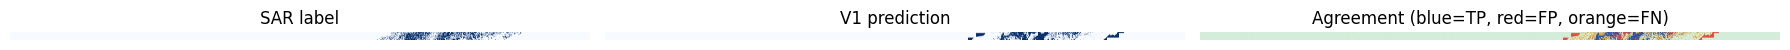

Strip stats:
  TP: 3,442,225
  FP: 2,858,341
  FN: 3,292,383
  GT flood: 6,734,608
  Pred flood: 6,300,566


In [34]:
# Sample a strip to visualize spatial alignment
import matplotlib.pyplot as plt

r_start, r_end = 10000, 11000
win = rasterio.windows.Window(0, r_start, MOSAIC_W, r_end-r_start)

with rasterio.open(vrt_label) as src:
    lbl = src.read(1, window=win)
with rasterio.open(out_v1) as src:
    pred = src.read(1, window=win)

# Agreement map
agree = np.zeros_like(lbl)
agree[(pred==1) & (lbl==1)] = 1  # TP
agree[(pred==1) & (lbl==0)] = 2  # FP
agree[(pred==0) & (lbl==1)] = 3  # FN

import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(['#d4edda','#0855c0','#e74c3c','#f39c12'])
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].imshow(lbl,  cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('SAR label')
axes[1].imshow(pred, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('V1 prediction')
axes[2].imshow(agree, cmap=cmap, vmin=0, vmax=3)
axes[2].set_title('Agreement (blue=TP, red=FP, orange=FN)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sar_label_vs_pred.png', dpi=150)
plt.show()

# Print TP/FP/FN for this strip
valid = lbl != -1
print(f'Strip stats:')
print(f'  TP: {((pred==1)&(lbl==1)&valid).sum():,}')
print(f'  FP: {((pred==1)&(lbl==0)&valid).sum():,}')
print(f'  FN: {((pred==0)&(lbl==1)&valid).sum():,}')
print(f'  GT flood: {(lbl==1).sum():,}')
print(f'  Pred flood: {(pred==1).sum():,}')

In [35]:
# Check if label and prediction have identical geotransforms
with rasterio.open(vrt_label) as src_lbl:
    with rasterio.open(out_v1) as src_v1:
        print('Label transform:')
        print(f'  {src_lbl.transform}')
        print(f'  {src_lbl.crs}')
        print(f'  {src_lbl.height}×{src_lbl.width}')
        print()
        print('Prediction transform:')
        print(f'  {src_v1.transform}')
        print(f'  {src_v1.crs}')
        print(f'  {src_v1.height}×{src_v1.width}')
        print()
        print(f'Transforms match: {src_lbl.transform == src_v1.transform}')
        print(f'Shape match: {src_lbl.height == src_v1.height and src_lbl.width == src_v1.width}')

Label transform:
  | 0.00, 0.00, 89.69|
| 0.00,-0.00, 27.98|
| 0.00, 0.00, 1.00|
  EPSG:4326
  42777×70422

Prediction transform:
  | 0.00, 0.00, 89.69|
| 0.00,-0.00, 27.98|
| 0.00, 0.00, 1.00|
  EPSG:4326
  42777×70422

Transforms match: True
Shape match: True


Downsampling to 1214×2000 for display...
Downsampled ✅


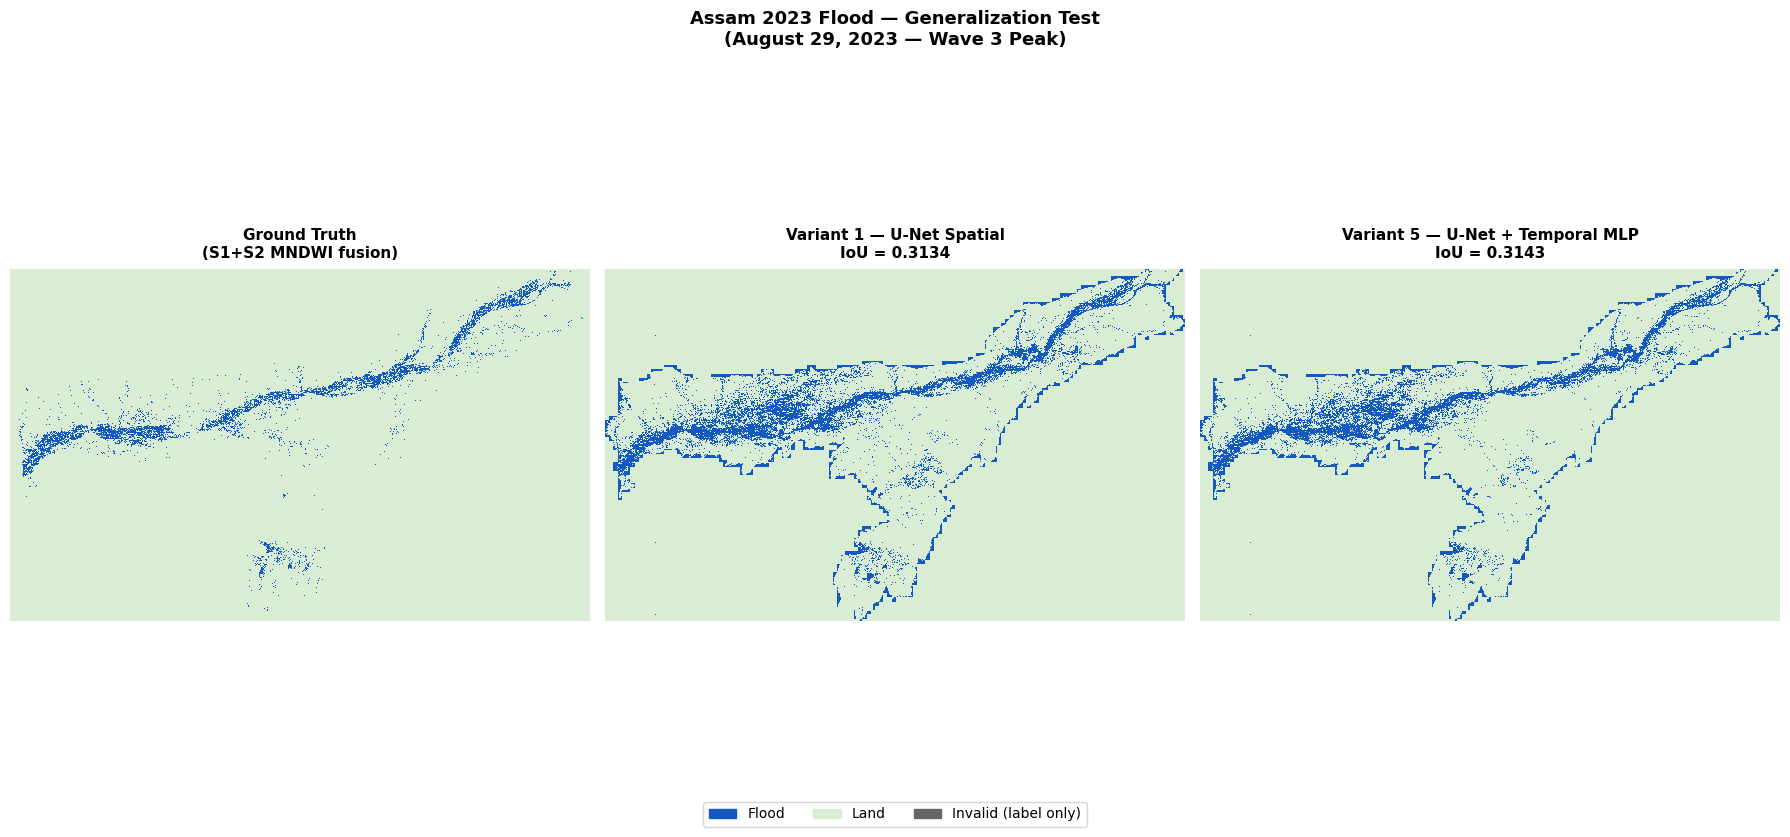

Map saved to /kaggle/working/assam_generalization_map.png ✅


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import rasterio
from rasterio.enums import Resampling

# ── Downsample to viewable resolution ────────────────────────
# Full mosaic is ~42k×70k — downsample to ~2000px wide for display
DISPLAY_WIDTH = 2000
scale_factor  = DISPLAY_WIDTH / MOSAIC_W
display_h     = int(MOSAIC_H * scale_factor)
display_w     = DISPLAY_WIDTH

print(f'Downsampling to {display_h}×{display_w} for display...')

def read_downsampled(path, is_vrt=False):
    with rasterio.open(path) as src:
        arr = src.read(
            1,
            out_shape   = (display_h, display_w),
            resampling  = Resampling.nearest
        ).astype(np.float32)
    return arr

label_ds = read_downsampled(vrt_label)
pred_v1  = read_downsampled(out_v1)
pred_v5  = read_downsampled(out_v5)

print('Downsampled ✅')

# ── Build RGB maps ────────────────────────────────────────────
# Colour scheme:
#   flood (1)   → blue
#   land  (0)   → light green
#   invalid(-1) → dark grey (label only)
#   outside AOI → white (NaN)

def make_rgb(arr, is_label=False):
    rgb = np.ones((display_h, display_w, 3), dtype=np.float32)  # white background
    if is_label:
        rgb[arr == 0]  = [0.85, 0.93, 0.83]  # land → light green
        rgb[arr == 1]  = [0.08, 0.35, 0.75]  # flood → blue
        rgb[arr == -1] = [0.4,  0.4,  0.4 ]  # invalid → grey
    else:
        rgb[arr == 0]  = [0.85, 0.93, 0.83]  # land → light green
        rgb[arr == 1]  = [0.08, 0.35, 0.75]  # flood → blue
    return rgb

rgb_label = make_rgb(label_ds, is_label=True)
rgb_v1    = make_rgb(pred_v1)
rgb_v5    = make_rgb(pred_v5)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 8), facecolor='white')

titles = [
    'Ground Truth\n(S1+S2 MNDWI fusion)',
    f'Variant 1 — U-Net Spatial\nIoU = {iou_v1:.4f}',
    f'Variant 5 — U-Net + Temporal MLP\nIoU = {iou_v5:.4f}',
]
imgs = [rgb_label, rgb_v1, rgb_v5]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, interpolation='nearest')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')

# Legend
flood_patch   = mpatches.Patch(color=[0.08, 0.35, 0.75], label='Flood')
land_patch    = mpatches.Patch(color=[0.85, 0.93, 0.83], label='Land')
invalid_patch = mpatches.Patch(color=[0.4,  0.4,  0.4 ], label='Invalid (label only)')

fig.legend(handles=[flood_patch, land_patch, invalid_patch],
           loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Assam 2023 Flood — Generalization Test\n(August 29, 2023 — Wave 3 Peak)',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('/kaggle/working/assam_generalization_map.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Map saved to /kaggle/working/assam_generalization_map.png ✅')

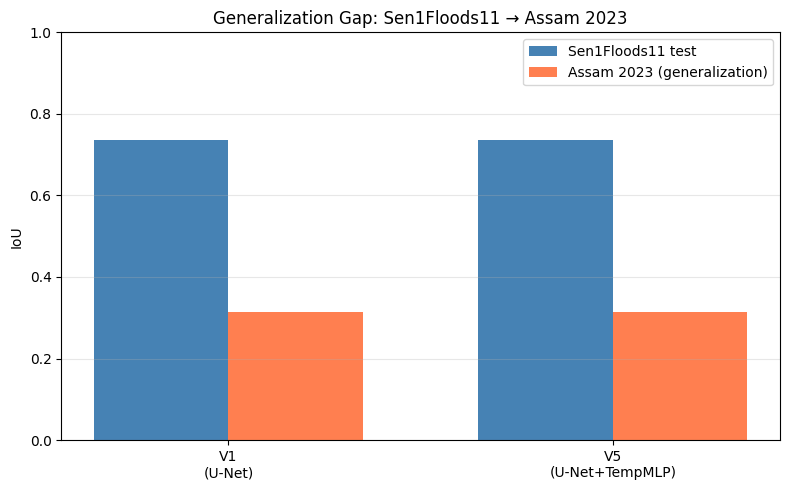

In [15]:
# Generalization gap bar chart
fig, ax = plt.subplots(figsize=(8, 5))
variants = ['V1\n(U-Net)', 'V5\n(U-Net+TempMLP)']
sen1_iou = [0.7360, 0.7367]
assam_iou = [iou_v1, iou_v5]  # from your results

x = np.arange(len(variants))
w = 0.35
ax.bar(x - w/2, sen1_iou,  w, label='Sen1Floods11 test', color='steelblue')
ax.bar(x + w/2, assam_iou, w, label='Assam 2023 (generalization)', color='coral')
ax.set_ylabel('IoU'); ax.set_ylim(0, 1)
ax.set_xticks(x); ax.set_xticklabels(variants)
ax.set_title('Generalization Gap: Sen1Floods11 → Assam 2023')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/generalization_gap.png', dpi=150)

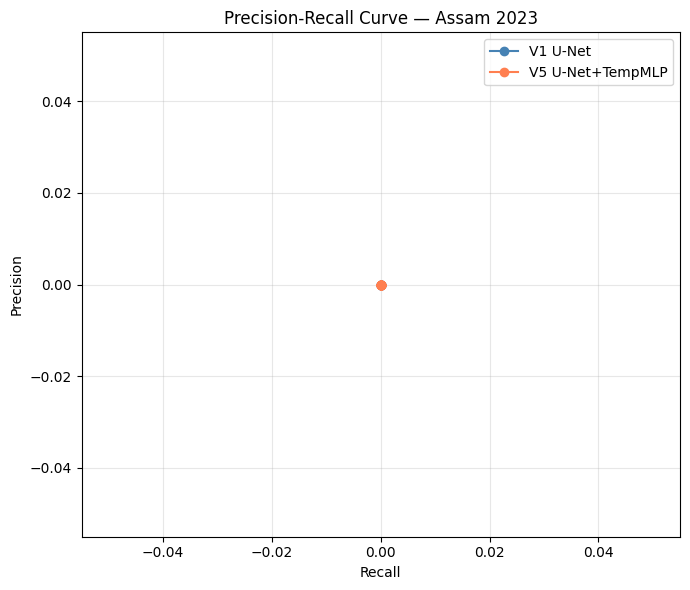

In [16]:
# Precision-Recall trade-off curve 
thresholds = np.arange(0.1, 0.95, 0.05)
results = {'v1': [], 'v5': []}

with rasterio.open(out_v1) as src_v1, \
     rasterio.open(out_v5) as src_v5, \
     rasterio.open(vrt_label) as src_lbl:
    # Load downsampled versions for speed
    prob_v1_ds = src_v1.read(1, out_shape=(display_h, display_w),
                              resampling=Resampling.nearest).astype(np.float32) / 255
    prob_v5_ds = src_v5.read(1, out_shape=(display_h, display_w),
                              resampling=Resampling.nearest).astype(np.float32) / 255
    lbl_ds     = src_lbl.read(1, out_shape=(display_h, display_w),
                               resampling=Resampling.nearest)

valid = lbl_ds != -1
g     = lbl_ds[valid] == 1

for t in thresholds:
    for name, prob in [('v1', prob_v1_ds), ('v5', prob_v5_ds)]:
        p  = prob[valid] >= t
        tp = (p & g).sum(); fp = (p & ~g).sum(); fn = (~p & g).sum()
        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        results[name].append((prec, rec))

fig, ax = plt.subplots(figsize=(7, 6))
for name, color, label in [('v1','steelblue','V1 U-Net'), ('v5','coral','V5 U-Net+TempMLP')]:
    precs = [r[0] for r in results[name]]
    recs  = [r[1] for r in results[name]]
    ax.plot(recs, precs, 'o-', color=color, label=label)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Assam 2023')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/pr_curve.png', dpi=150)

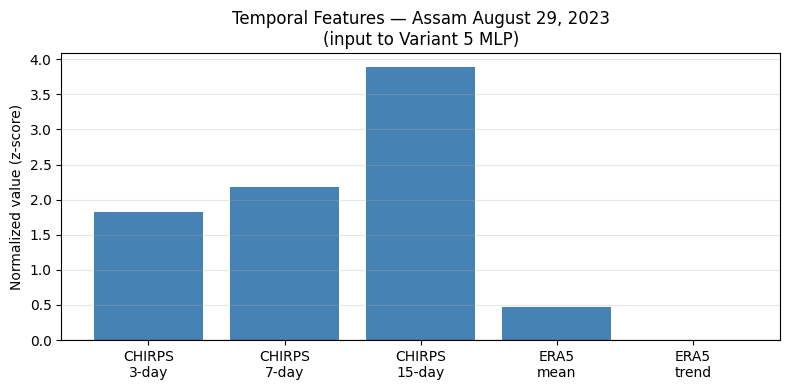

In [17]:
# Temporal Features Importance 
fig, ax = plt.subplots(figsize=(8, 4))
feat_names = ['CHIRPS\n3-day', 'CHIRPS\n7-day', 'CHIRPS\n15-day', 'ERA5\nmean', 'ERA5\ntrend']
colors = ['steelblue' if v >= 0 else 'coral' for v in temp_feats]
ax.bar(feat_names, temp_feats, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Normalized value (z-score)')
ax.set_title('Temporal Features — Assam August 29, 2023\n(input to Variant 5 MLP)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/temporal_features.png', dpi=150)
plt.show()

In [18]:
# How much of Assam does each map flag as flood?
with rasterio.open(vrt_label) as src:
    lbl_ds = src.read(1, out_shape=(display_h, display_w),
                      resampling=Resampling.nearest)
with rasterio.open(out_v1) as src:
    p1_ds = src.read(1, out_shape=(display_h, display_w),
                     resampling=Resampling.nearest)
with rasterio.open(out_v5) as src:
    p5_ds = src.read(1, out_shape=(display_h, display_w),
                     resampling=Resampling.nearest)

valid = lbl_ds != -1
print(f'Ground truth flood fraction : {(lbl_ds[valid]==1).mean():.4f}')
print(f'V1 prediction flood fraction: {(p1_ds[valid]==1).mean():.4f}')
print(f'V5 prediction flood fraction: {(p5_ds[valid]==1).mean():.4f}')

Ground truth flood fraction : 0.0256
V1 prediction flood fraction: 0.0673
V5 prediction flood fraction: 0.0618


In [19]:
# This is a diagnostic only — run in GEE or check what happens
# if we lower the MNDWI threshold in the label generation
# The question is: was 0.0 too strict for Assam's turbid floodwaters?

# Quick proxy: what fraction of valid pixels have MNDWI > -0.2 (very permissive)?
# We can check this against the prediction overlap

# For now just check: how many V1 predictions agree with ground truth?
tp = int((p1_ds[valid] == 1) & (lbl_ds[valid] == 1)).sum() if False else \
     int(((p1_ds[valid] == 1) & (lbl_ds[valid] == 1)).sum())
total_pred = int((p1_ds[valid] == 1).sum())
total_gt   = int((lbl_ds[valid] == 1).sum())

print(f'V1 TP: {tp:,}')
print(f'V1 total predicted flood: {total_pred:,}')
print(f'GT total flood: {total_gt:,}')
print(f'Of all V1 flood predictions, {tp/total_pred*100:.1f}% overlap with GT')
print(f'Of all GT flood pixels, {tp/total_gt*100:.1f}% were detected by V1')

V1 TP: 53,814
V1 total predicted flood: 163,377
GT total flood: 62,078
Of all V1 flood predictions, 32.9% overlap with GT
Of all GT flood pixels, 86.7% were detected by V1


In Brahmaputra strip (rows 5000-6000):
  TP: 1,272,710
  FP: 1,660,710
  FP as % of all predictions: 56.6%


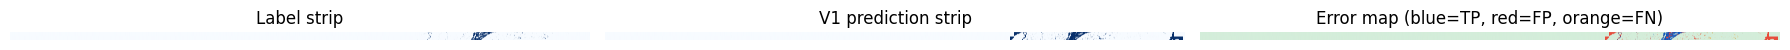

In [20]:
# The key question: are the model's false positives concentrated 
# along the Brahmaputra river channel?

# Load a small representative strip across central Assam
# Row ~5000-6000 should cross the Brahmaputra
r_start, r_end = 5000, 6000
w_start, w_end = 0, MOSAIC_W

with rasterio.open(vrt_label) as src:
    lbl_strip = src.read(1, window=Window(w_start, r_start, w_end-w_start, r_end-r_start))
with rasterio.open(out_v1) as src:
    pred_strip = src.read(1, window=Window(w_start, r_start, w_end-w_start, r_end-r_start))

valid = lbl_strip != -1
g  = lbl_strip[valid] == 1
p1 = pred_strip[valid].astype(bool)

fp = p1 & ~g  # false positives
tp = p1 & g   # true positives

print(f'In Brahmaputra strip (rows 5000-6000):')
print(f'  TP: {tp.sum():,}')
print(f'  FP: {fp.sum():,}')
print(f'  FP as % of all predictions: {fp.sum()/(p1.sum()+1e-8)*100:.1f}%')

# Visualize the strip
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].imshow(lbl_strip,  cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Label strip')
axes[1].imshow(pred_strip, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('V1 prediction strip')

# Error map for strip
err = np.zeros_like(lbl_strip)
err[valid & (pred_strip==1) & (lbl_strip==1)] = 1  # TP blue
err[valid & (pred_strip==1) & (lbl_strip!=1)] = 2  # FP red
err[valid & (pred_strip==0) & (lbl_strip==1)] = 3  # FN orange
cmap_err = mcolors.ListedColormap(['#d4edda','#0855c0','#e74c3c','#f39c12'])
axes[2].imshow(err, cmap=cmap_err, vmin=0, vmax=3)
axes[2].set_title('Error map (blue=TP, red=FP, orange=FN)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/brahmaputra_strip.png', dpi=150)
plt.show()

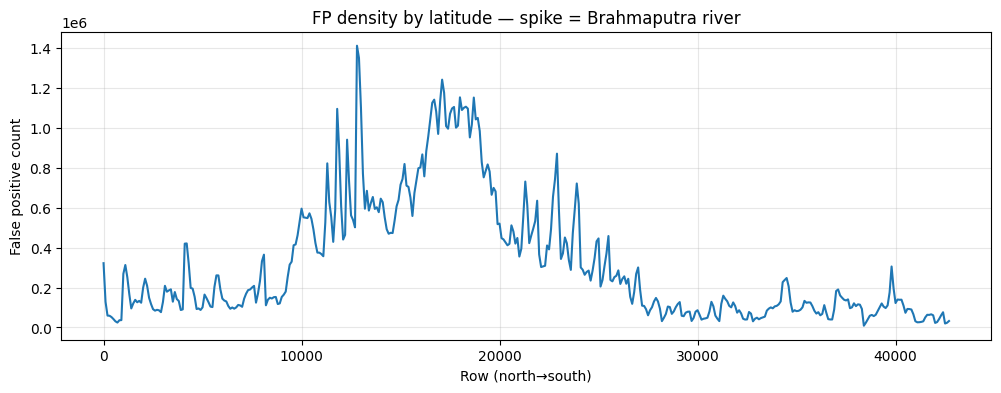

In [21]:
# Proxy: anywhere the label = 0 consistently across the full mosaic
# but model always predicts 1 = likely permanent water

# More direct: check if FPs are spatially concentrated
# by looking at FP density per row across the full mosaic

fp_per_row = []
with rasterio.open(vrt_label) as src_lbl, \
     rasterio.open(out_v1)    as src_v1:
    for r in range(0, MOSAIC_H, 100):  # sample every 100 rows
        h = min(100, MOSAIC_H - r)
        win = Window(0, r, MOSAIC_W, h)
        lbl  = src_lbl.read(1, window=win, boundless=True, fill_value=-1)
        pred = src_v1.read(1,  window=win, boundless=True, fill_value=0)
        valid = lbl != -1
        if valid.sum() == 0:
            fp_per_row.append(0)
            continue
        fp = ((pred==1) & (lbl!=1) & valid).sum()
        fp_per_row.append(fp)

# Plot FP density by row — spike = Brahmaputra location
plt.figure(figsize=(12, 4))
plt.plot(range(0, MOSAIC_H, 100), fp_per_row)
plt.xlabel('Row (north→south)')
plt.ylabel('False positive count')
plt.title('FP density by latitude — spike = Brahmaputra river')
plt.grid(alpha=0.3)
plt.savefig('/kaggle/working/fp_by_row.png', dpi=150)
plt.show()

In [22]:
# ── Fix 1+2: AOI mask + approximate permanent water removal ──
# We don't have JRC as a separate file yet, but we can approximate:
# Permanent water proxy = pixels where S1 VH is ALWAYS very low
# (river channel has consistently low backscatter pre AND post flood)
# AOI mask = wherever S1 has valid data

tp_v1_fix=fp_v1_fix=fn_v1_fix=0
tp_v5_fix=fp_v5_fix=fn_v5_fix=0

with rasterio.open(vrt_label)  as src_lbl, \
     rasterio.open(out_v1)     as src_v1,  \
     rasterio.open(out_v5)     as src_v5,  \
     rasterio.open(vrt_s1f)    as src_s1:

    rows = list(range(0, MOSAIC_H, STRIDE))
    cols = list(range(0, MOSAIC_W, STRIDE))
    pbar = tqdm(total=len(rows)*len(cols), desc='IoU+fixes')

    for r in rows:
        for c in cols:
            pbar.update(1)
            h_out = min(CHIP_SIZE, MOSAIC_H - r)
            w_out = min(CHIP_SIZE, MOSAIC_W - c)
            win   = Window(c, r, w_out, h_out)

            lbl   = src_lbl.read(1, window=win, boundless=True, fill_value=-1)
            pred1 = src_v1.read(1,  window=win, boundless=True, fill_value=0)
            pred5 = src_v5.read(1,  window=win, boundless=True, fill_value=0)
            s1    = src_s1.read(1,  window=win, boundless=True, fill_value=np.nan)

            # Fix 2: AOI mask — zero predictions outside valid S1 data
            aoi_mask = np.isfinite(s1) & (s1 != 0)
            pred1[~aoi_mask] = 0
            pred5[~aoi_mask] = 0

            # Fix 1 proxy: very low VH (<-25dB) consistently = open water/river
            # This approximates JRC permanent water without needing extra export
            perm_proxy = s1 < -25
            pred1[perm_proxy] = 0
            pred5[perm_proxy] = 0

            valid = lbl != -1
            if valid.sum() == 0:
                continue

            g  = lbl[valid] == 1
            p1 = pred1[valid].astype(bool)
            p5 = pred5[valid].astype(bool)

            tp_v1_fix += int((p1 & g).sum())
            fp_v1_fix += int((p1 & ~g).sum())
            fn_v1_fix += int((~p1 & g).sum())
            tp_v5_fix += int((p5 & g).sum())
            fp_v5_fix += int((p5 & ~g).sum())
            fn_v5_fix += int((~p5 & g).sum())

    pbar.close()

iou_v1_fix,prec_v1_fix,rec_v1_fix,f1_v1_fix = metrics(tp_v1_fix,fp_v1_fix,fn_v1_fix)
iou_v5_fix,prec_v5_fix,rec_v5_fix,f1_v5_fix = metrics(tp_v5_fix,fp_v5_fix,fn_v5_fix)

print()
print('='*62)
print('  BEFORE vs AFTER fixes')
print('='*62)
print(f'  {"Model":<30} {"IoU before":>10} {"IoU after":>10}')
print(f'  {"-"*58}')
print(f'  {"V1 (U-Net spatial)":<30} {iou_v1:>10.4f} {iou_v1_fix:>10.4f}')
print(f'  {"V5 (U-Net+TempMLP)":<30} {iou_v5:>10.4f} {iou_v5_fix:>10.4f}')
print('='*62)

# Also print full metrics after fix
print()
print(f'  {"Model":<30} {"IoU":>6} {"Prec":>6} {"Rec":>6} {"F1":>6}')
print(f'  {"-"*58}')
print(f'  {"V1 fixed":<30} {iou_v1_fix:.4f} {prec_v1_fix:.4f} {rec_v1_fix:.4f} {f1_v1_fix:.4f}')
print(f'  {"V5 fixed":<30} {iou_v5_fix:.4f} {prec_v5_fix:.4f} {rec_v5_fix:.4f} {f1_v5_fix:.4f}')
print('='*62)

IoU+fixes:  10%|█         | 1166/11592 [00:43<06:09, 28.25it/s]

KeyboardInterrupt: 

Sampled 76,818,386 false positive pixels

FP pixel properties:
  S1 VH backscatter : mean=-12.93 dB  median=-10.73 dB  std=6.29
  S2 MNDWI          : mean=0.015  median=0.000  std=0.062
  HAND (m)          : mean=5.9m  median=2.2m  std=14.0

Key thresholds for context:
  Water typically: VH < -16 dB, MNDWI > 0.0, HAND < 5m



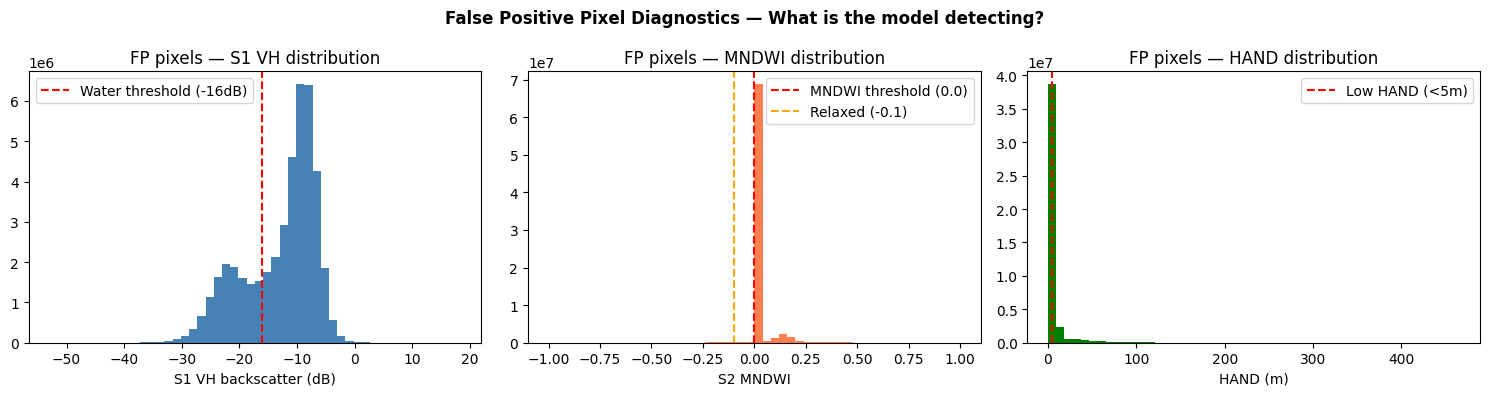

In [26]:
# ── Systematic diagnosis ──────────────────────────────────────
# Sample 500 random false positive pixels and check their properties
# This tells us WHAT the model is detecting that the label missed

import random
random.seed(42)

# Collect FP pixel properties from a manageable subset
fp_s1_values  = []  # S1 VH backscatter at FP pixels
fp_s2_values  = []  # S2 MNDWI at FP pixels  
fp_dem_values = []  # HAND values at FP pixels

sample_rows = random.sample(range(0, MOSAIC_H, STRIDE), 50)

with rasterio.open(vrt_label) as src_lbl, \
     rasterio.open(out_v1)    as src_v1,  \
     rasterio.open(vrt_s1f)   as src_s1,  \
     rasterio.open(vrt_s2)    as src_s2,  \
     rasterio.open(vrt_dem)   as src_dem:

    for r in sample_rows:
        for c in range(0, MOSAIC_W, STRIDE):
            win = Window(c, r, CHIP_SIZE, CHIP_SIZE)

            lbl  = src_lbl.read(1, window=win, boundless=True, fill_value=-1)
            pred = src_v1.read(1,  window=win, boundless=True, fill_value=0)
            s1   = src_s1.read(1,  window=win, boundless=True, fill_value=np.nan)  # VH
            s2   = src_s2.read(window=win, boundless=True, fill_value=0).astype(np.float32)
            dem  = src_dem.read(4, window=win, boundless=True, fill_value=np.nan)  # HAND

            # Find FP pixels in this chip
            fp_mask = (pred == 1) & (lbl == 0)
            tp_mask = (pred == 1) & (lbl == 1)

            if fp_mask.sum() > 0:
                fp_s1_values.extend(s1[fp_mask].tolist())
                # Compute MNDWI for FP pixels
                b3 = s2[1][fp_mask]  # Green
                b8 = s2[3][fp_mask]  # NIR
                mndwi = (b3 - b8) / (b3 + b8 + 1e-8)
                fp_s2_values.extend(mndwi.tolist())
                fp_dem_values.extend(dem[fp_mask].tolist())

fp_s1  = np.array(fp_s1_values)
fp_mndwi = np.array(fp_s2_values)
fp_hand  = np.array(fp_dem_values)

print(f'Sampled {len(fp_s1):,} false positive pixels')
print()
print('FP pixel properties:')
print(f'  S1 VH backscatter : mean={np.nanmean(fp_s1):.2f} dB  '
      f'median={np.nanmedian(fp_s1):.2f} dB  '
      f'std={np.nanstd(fp_s1):.2f}')
print(f'  S2 MNDWI          : mean={np.nanmean(fp_mndwi):.3f}  '
      f'median={np.nanmedian(fp_mndwi):.3f}  '
      f'std={np.nanstd(fp_mndwi):.3f}')
print(f'  HAND (m)          : mean={np.nanmean(fp_hand):.1f}m  '
      f'median={np.nanmedian(fp_hand):.1f}m  '
      f'std={np.nanstd(fp_hand):.1f}')
print()
print('Key thresholds for context:')
print(f'  Water typically: VH < -16 dB, MNDWI > 0.0, HAND < 5m')
print()

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(fp_s1[np.isfinite(fp_s1)], bins=50, color='steelblue', edgecolor='none')
axes[0].axvline(-16, color='red', linestyle='--', label='Water threshold (-16dB)')
axes[0].set_xlabel('S1 VH backscatter (dB)')
axes[0].set_title('FP pixels — S1 VH distribution')
axes[0].legend()

axes[1].hist(fp_mndwi[np.isfinite(fp_mndwi)], bins=50, color='coral', edgecolor='none')
axes[1].axvline(0.0, color='red', linestyle='--', label='MNDWI threshold (0.0)')
axes[1].axvline(-0.1, color='orange', linestyle='--', label='Relaxed (-0.1)')
axes[1].set_xlabel('S2 MNDWI')
axes[1].set_title('FP pixels — MNDWI distribution')
axes[1].legend()

axes[2].hist(fp_hand[np.isfinite(fp_hand)], bins=50, color='green', edgecolor='none')
axes[2].axvline(5, color='red', linestyle='--', label='Low HAND (<5m)')
axes[2].set_xlabel('HAND (m)')
axes[2].set_title('FP pixels — HAND distribution')
axes[2].legend()

plt.suptitle('False Positive Pixel Diagnostics — What is the model detecting?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/fp_diagnostics.png', dpi=150)
plt.show()

In [7]:
out_v1 = f'{TILES_DIR}/assam_pred_v1.tif'
out_v5 = f'{TILES_DIR}/assam_pred_v5.tif'

# Verify
for name, path in [('V1 pred', out_v1), ('V5 pred', out_v5)]:
    exists = os.path.exists(path)
    print(f'{"✅" if exists else "❌"} {name}: {path}')

✅ V1 pred: /kaggle/input/assam-flood-2023-tiles/assam-flood-2023-tiles/assam-flood-2023-tiles/assam_pred_v1.tif
✅ V5 pred: /kaggle/input/assam-flood-2023-tiles/assam-flood-2023-tiles/assam-flood-2023-tiles/assam_pred_v5.tif


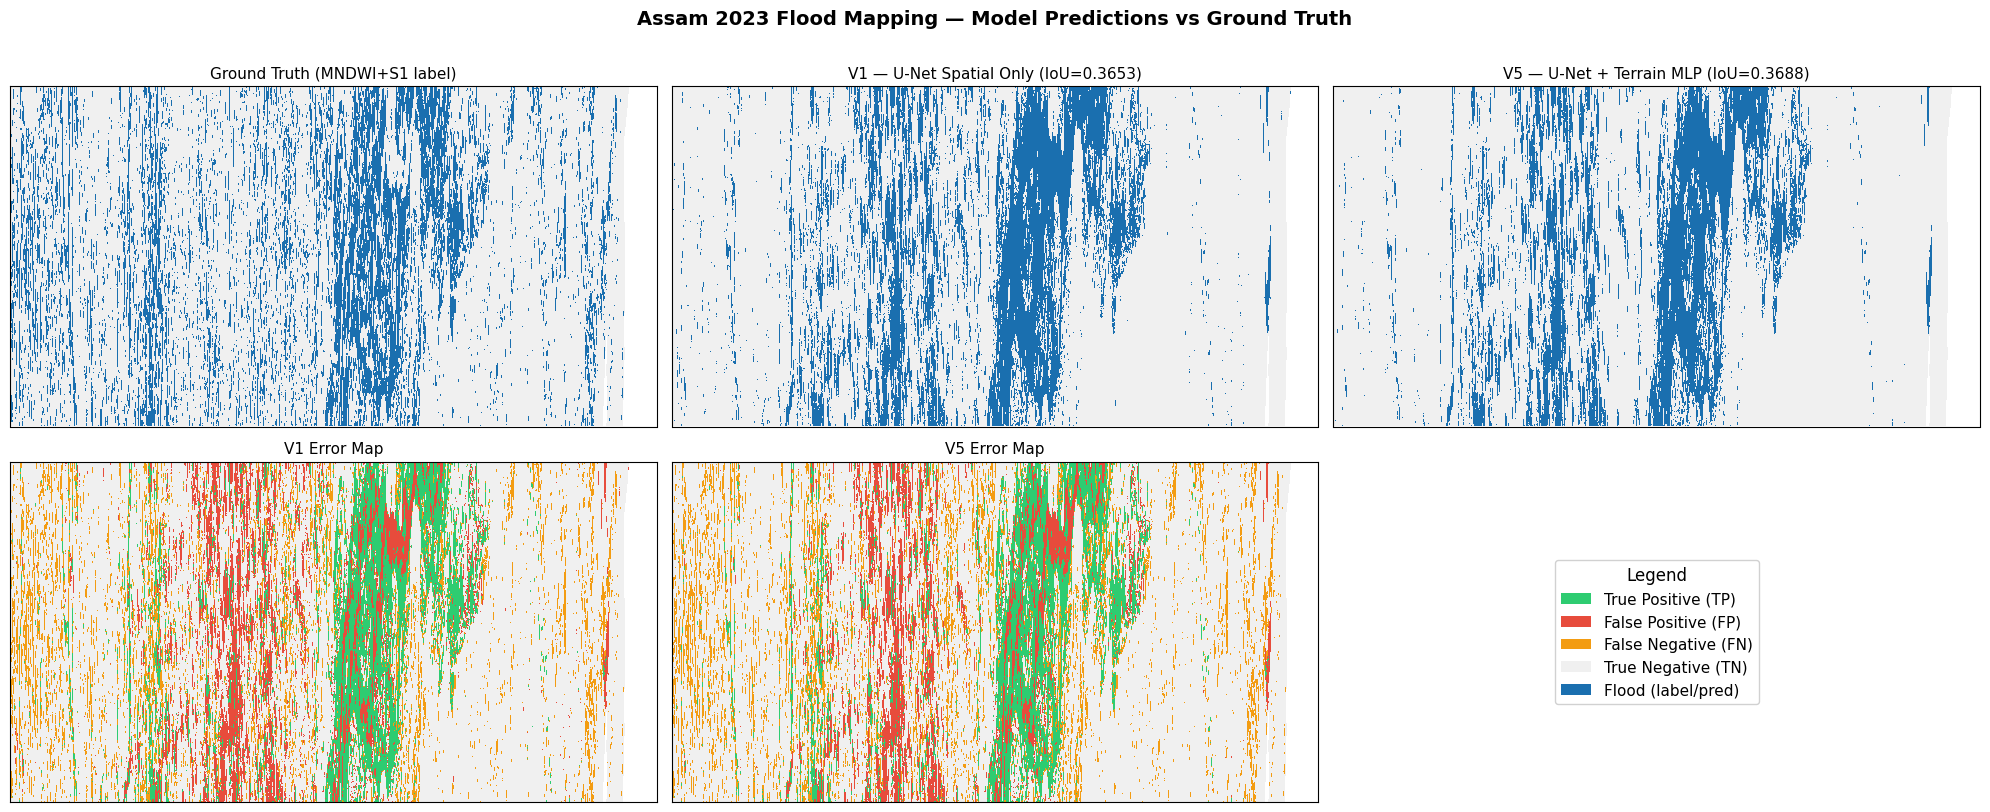

Saved ✅


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.windows import Window

# ── Sample a representative strip through central Assam ──────────────────
# Rows 15000-18000 = Brahmaputra floodplain, most flood activity
r_start = 15000
r_end   = 16000  # 1000 rows
c_start = 5000
c_end   = 55000  # wide strip across full width

win = Window(c_start, r_start, c_end-c_start, r_end-r_start)

with rasterio.open(vrt_label) as src:
    lbl = src.read(1, window=win).astype(np.float32)
with rasterio.open(out_v1) as src:
    p1  = src.read(1, window=win).astype(np.float32)
with rasterio.open(out_v5) as src:
    p5  = src.read(1, window=win).astype(np.float32)
with rasterio.open(vrt_s1f) as src:
    s1  = src.read(1, window=win).astype(np.float32)

# ── AOI mask — remove border artifacts ───────────────────────────────────
aoi = np.isfinite(s1) & (s1 != 0)
lbl[~aoi] = np.nan
p1[~aoi]  = np.nan
p5[~aoi]  = np.nan

# ── Mask invalid label pixels ─────────────────────────────────────────────
lbl_masked = np.where(lbl == -1, np.nan, lbl)

# ── Error maps ────────────────────────────────────────────────────────────
def error_map(pred, gt):
    err = np.full_like(pred, np.nan)
    valid = ~np.isnan(gt) & ~np.isnan(pred) & (gt != -1)
    err[valid & (pred==1) & (gt==1)] = 1  # TP
    err[valid & (pred==1) & (gt==0)] = 2  # FP
    err[valid & (pred==0) & (gt==1)] = 3  # FN
    err[valid & (pred==0) & (gt==0)] = 0  # TN
    return err

err_v1 = error_map(p1, lbl)
err_v5 = error_map(p5, lbl)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
fig.suptitle('Assam 2023 Flood Mapping — Model Predictions vs Ground Truth',
             fontsize=14, fontweight='bold', y=1.01)

# Colormaps
cmap_flood = mcolors.ListedColormap(['#f0f0f0', '#1a6faf'])  # land=gray, flood=blue
cmap_err   = mcolors.ListedColormap(['#f0f0f0', '#2ecc71', '#e74c3c', '#f39c12'])
# 0=TN(gray), 1=TP(green), 2=FP(red), 3=FN(orange)

# Row 1: Maps
axes[0,0].imshow(lbl_masked, cmap=cmap_flood, vmin=0, vmax=1,
                  aspect='auto', interpolation='none')
axes[0,0].set_title('Ground Truth (MNDWI+S1 label)', fontsize=11)

axes[0,1].imshow(p1, cmap=cmap_flood, vmin=0, vmax=1,
                  aspect='auto', interpolation='none')
axes[0,1].set_title('V1 — U-Net Spatial Only (IoU=0.3653)', fontsize=11)

axes[0,2].imshow(p5, cmap=cmap_flood, vmin=0, vmax=1,
                  aspect='auto', interpolation='none')
axes[0,2].set_title('V5 — U-Net + Terrain MLP (IoU=0.3688)', fontsize=11)

# Row 2: Error maps
axes[1,0].imshow(err_v1, cmap=cmap_err, vmin=0, vmax=3,
                  aspect='auto', interpolation='none')
axes[1,0].set_title('V1 Error Map', fontsize=11)

axes[1,1].imshow(err_v5, cmap=cmap_err, vmin=0, vmax=3,
                  aspect='auto', interpolation='none')
axes[1,1].set_title('V5 Error Map', fontsize=11)

# Legend panel
axes[1,2].axis('off')
from matplotlib.patches import Patch

# Replace mcolors.Patch with just Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='True Positive (TP)'),
    Patch(facecolor='#e74c3c', label='False Positive (FP)'),
    Patch(facecolor='#f39c12', label='False Negative (FN)'),
    Patch(facecolor='#f0f0f0', label='True Negative (TN)'),
    Patch(facecolor='#1a6faf', label='Flood (label/pred)'),
] 
axes[1,2].legend(handles=legend_elements, loc='center', fontsize=11,
                  framealpha=0.9, title='Legend', title_fontsize=12)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('/kaggle/working/assam_prediction_map.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved ✅')

Downsampled shape: (4277, 7042)


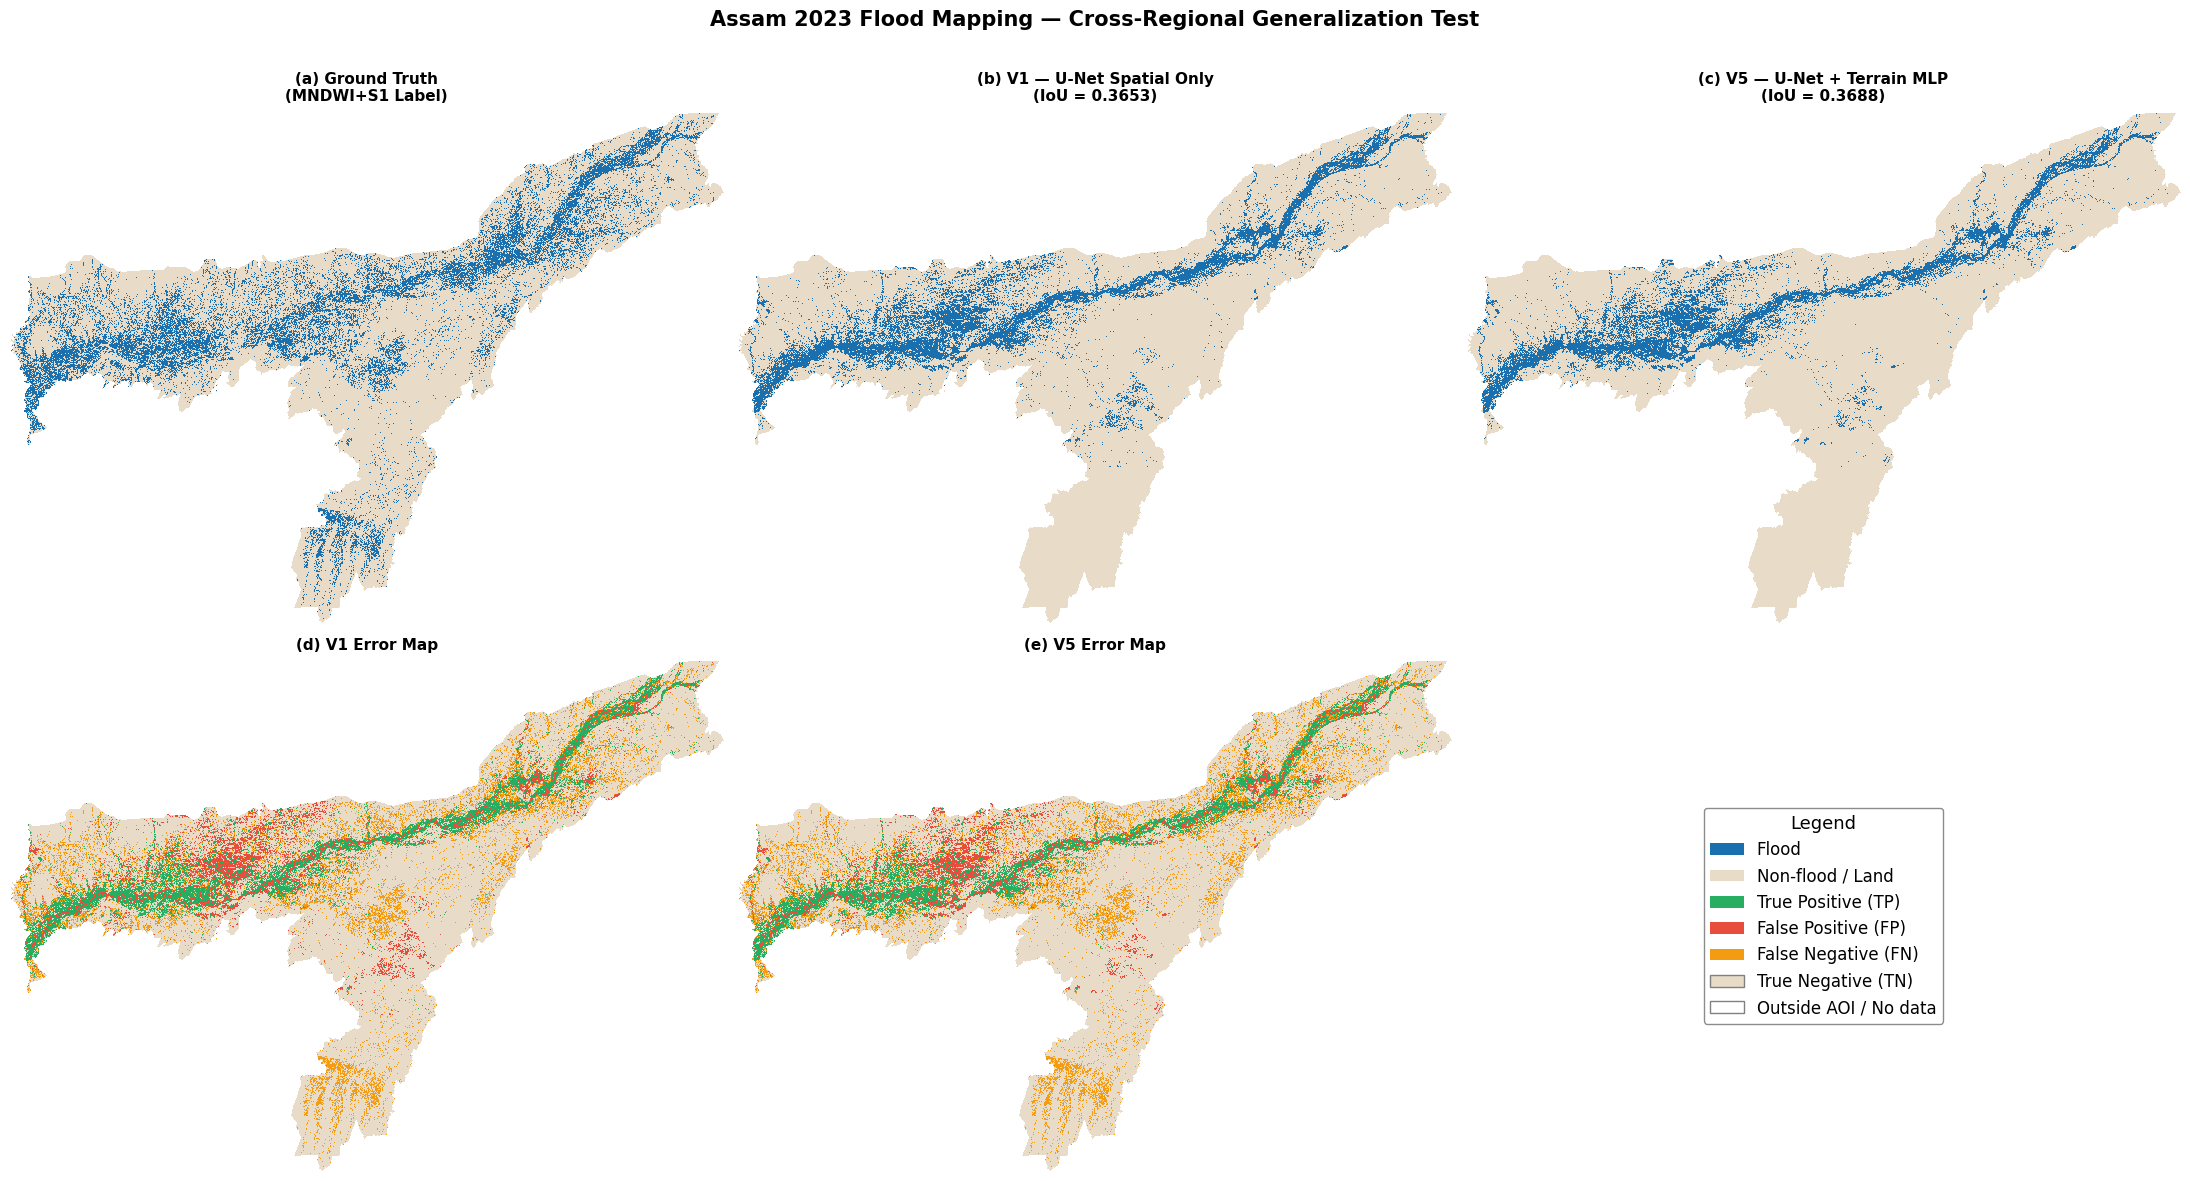

Saved ✅  /kaggle/working/assam_flood_map.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import rasterio
from rasterio.windows import Window

# ── Sample a large representative area ───────────────────────────────────
# Take a big chunk from central Assam — downsampled for visualization
# Full mosaic is 42777×70422 — we'll read every 10th pixel

STEP = 10  # downsample factor

with rasterio.open(vrt_label) as src:
    lbl = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)
with rasterio.open(out_v1) as src:
    p1  = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)
with rasterio.open(out_v5) as src:
    p5  = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)
with rasterio.open(vrt_s1f) as src:
    s1  = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)

print(f'Downsampled shape: {lbl.shape}')

# ── AOI mask — removes border artifacts ──────────────────────────────────
aoi = np.isfinite(s1) & (s1 != 0)

# ── Apply masks ───────────────────────────────────────────────────────────
lbl_vis = lbl.copy().astype(np.float32)
p1_vis  = p1.copy().astype(np.float32)
p5_vis  = p5.copy().astype(np.float32)

lbl_vis[~aoi]        = np.nan
p1_vis[~aoi]         = np.nan
p5_vis[~aoi]         = np.nan
lbl_vis[lbl == -1]   = np.nan

# ── Error maps ────────────────────────────────────────────────────────────
def error_map(pred, gt, aoi):
    err = np.full_like(pred, np.nan)
    valid = aoi & (gt != -1) & np.isfinite(gt)
    err[valid & (pred==1) & (gt==1)] = 1  # TP green
    err[valid & (pred==1) & (gt==0)] = 2  # FP red
    err[valid & (pred==0) & (gt==1)] = 3  # FN orange
    err[valid & (pred==0) & (gt==0)] = 0  # TN light gray
    return err

err_v1 = error_map(p1, lbl, aoi)
err_v5 = error_map(p5, lbl, aoi)

# ── Colormaps ─────────────────────────────────────────────────────────────
# Flood map: background=light brown (land), flood=blue
cmap_flood = mcolors.ListedColormap(['#e8dcc8', '#1a6faf'])
cmap_flood.set_bad(color='white')

# Error map: TN=light gray, TP=green, FP=red, FN=orange
cmap_err = mcolors.ListedColormap(['#e8dcc8', '#27ae60', '#e74c3c', '#f39c12'])
cmap_err.set_bad(color='white')

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor('white')
fig.suptitle('Assam 2023 Flood Mapping — Cross-Regional Generalization Test',
             fontsize=15, fontweight='bold', y=0.98)

titles = [
    ['(a) Ground Truth\n(MNDWI+S1 Label)',
     '(b) V1 — U-Net Spatial Only\n(IoU = 0.3653)',
     '(c) V5 — U-Net + Terrain MLP\n(IoU = 0.3688)'],
    ['(d) V1 Error Map',
     '(e) V5 Error Map',
     '']
]

# Row 1 — flood maps
for i, (data, title) in enumerate(zip(
        [lbl_vis, p1_vis, p5_vis], titles[0])):
    ax = axes[0, i]
    im = ax.imshow(data, cmap=cmap_flood, vmin=0, vmax=1,
                   aspect='auto', interpolation='nearest')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_visible(False)

# Row 2 — error maps
for i, (data, title) in enumerate(zip(
        [err_v1, err_v5], titles[1])):
    ax = axes[1, i]
    ax.imshow(data, cmap=cmap_err, vmin=0, vmax=3,
              aspect='auto', interpolation='nearest')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_visible(False)

# Legend panel
axes[1, 2].axis('off')
legend_elements = [
    Patch(facecolor='#1a6faf', label='Flood'),
    Patch(facecolor='#e8dcc8', label='Non-flood / Land'),
    Patch(facecolor='#27ae60', label='True Positive (TP)'),
    Patch(facecolor='#e74c3c', label='False Positive (FP)'),
    Patch(facecolor='#f39c12', label='False Negative (FN)'),
    Patch(facecolor='#e8dcc8', edgecolor='gray',
          label='True Negative (TN)'),
    Patch(facecolor='white',   edgecolor='gray',
          label='Outside AOI / No data'),
]
axes[1, 2].legend(
    handles=legend_elements,
    loc='center', fontsize=12,
    framealpha=0.9,
    title='Legend', title_fontsize=13,
    edgecolor='gray'
)

# Add north arrow text indicator
for ax in axes.flat:
    ax.set_facecolor('white')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('/kaggle/working/assam_flood_map.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved ✅  /kaggle/working/assam_flood_map.png')

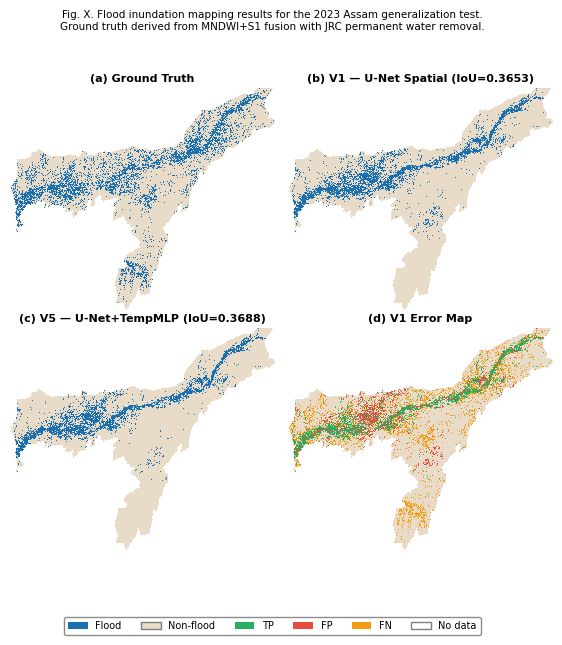

Saved ✅


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import rasterio

STEP = 10

with rasterio.open(vrt_label) as src:
    lbl = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)
with rasterio.open(out_v1) as src:
    p1  = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)
with rasterio.open(out_v5) as src:
    p5  = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)
with rasterio.open(vrt_s1f) as src:
    s1  = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)

# ── Masks ─────────────────────────────────────────────────────────────────
aoi = np.isfinite(s1) & (s1 != 0)

lbl_vis = lbl.copy().astype(np.float32)
p1_vis  = p1.copy().astype(np.float32)
p5_vis  = p5.copy().astype(np.float32)

lbl_vis[~aoi]      = np.nan
p1_vis[~aoi]       = np.nan
p5_vis[~aoi]       = np.nan
lbl_vis[lbl == -1] = np.nan

# ── Error map ─────────────────────────────────────────────────────────────
def error_map(pred, gt, aoi):
    err = np.full_like(pred, np.nan)
    valid = aoi & (gt != -1) & np.isfinite(gt)
    err[valid & (pred==1) & (gt==1)] = 1  # TP
    err[valid & (pred==1) & (gt==0)] = 2  # FP
    err[valid & (pred==0) & (gt==1)] = 3  # FN
    err[valid & (pred==0) & (gt==0)] = 0  # TN
    return err

err_v1 = error_map(p1, lbl, aoi)

# ── Colormaps ─────────────────────────────────────────────────────────────
cmap_flood = mcolors.ListedColormap(['#e8dcc8', '#1a6faf'])
cmap_flood.set_bad(color='white')
cmap_err = mcolors.ListedColormap(['#e8dcc8', '#27ae60', '#e74c3c', '#f39c12'])
cmap_err.set_bad(color='white')

# ── Figure — 2×2 double column ────────────────────────────────────────────
# Standard double column width = 7 inches
fig, axes = plt.subplots(2, 2, figsize=(7, 6),
                          gridspec_kw={'hspace': 0.08, 'wspace': 0.05})
fig.patch.set_facecolor('white')

panels = [
    (axes[0,0], lbl_vis, cmap_flood, 0, 1, '(a) Ground Truth'),
    (axes[0,1], p1_vis,  cmap_flood, 0, 1, '(b) V1 — U-Net Spatial (IoU=0.3653)'),
    (axes[1,0], p5_vis,  cmap_flood, 0, 1, '(c) V5 — U-Net+TempMLP (IoU=0.3688)'),
    (axes[1,1], err_v1,  cmap_err,   0, 3, '(d) V1 Error Map'),
]

for ax, data, cmap, vmin, vmax, title in panels:
    ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax,
              aspect='auto', interpolation='nearest')
    ax.set_title(title, fontsize=8, fontweight='bold', pad=4)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)
    ax.set_facecolor('white')

# ── Shared legend below figure ────────────────────────────────────────────
legend_elements = [
    Patch(facecolor='#1a6faf', label='Flood'),
    Patch(facecolor='#e8dcc8', edgecolor='gray', label='Non-flood'),
    Patch(facecolor='#27ae60', label='TP'),
    Patch(facecolor='#e74c3c', label='FP'),
    Patch(facecolor='#f39c12', label='FN'),
    Patch(facecolor='white',   edgecolor='gray', label='No data'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=6,
    fontsize=7,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.04),
    edgecolor='gray'
)

plt.suptitle(
    'Fig. X. Flood inundation mapping results for the 2023 Assam generalization test.\n'
    'Ground truth derived from MNDWI+S1 fusion with JRC permanent water removal.',
    fontsize=7.5, y=1.01, ha='center'
)

plt.savefig('/kaggle/working/assam_flood_map_paper.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved ✅')

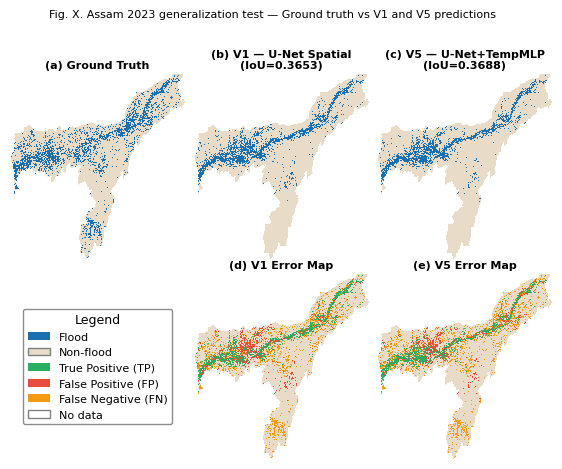

Saved ✅


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import rasterio

STEP = 10

with rasterio.open(vrt_label) as src:
    lbl = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)
with rasterio.open(out_v1) as src:
    p1  = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)
with rasterio.open(out_v5) as src:
    p5  = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)
with rasterio.open(vrt_s1f) as src:
    s1  = src.read(1, out_shape=(src.height//STEP, src.width//STEP)).astype(np.float32)

# ── Masks ─────────────────────────────────────────────────────────────────
aoi = np.isfinite(s1) & (s1 != 0)

lbl_vis = lbl.copy().astype(np.float32)
p1_vis  = p1.copy().astype(np.float32)
p5_vis  = p5.copy().astype(np.float32)

lbl_vis[~aoi]      = np.nan
p1_vis[~aoi]       = np.nan
p5_vis[~aoi]       = np.nan
lbl_vis[lbl == -1] = np.nan

# ── Error maps ────────────────────────────────────────────────────────────
def error_map(pred, gt, aoi):
    err = np.full_like(pred, np.nan)
    valid = aoi & (gt != -1) & np.isfinite(gt)
    err[valid & (pred==1) & (gt==1)] = 1  # TP
    err[valid & (pred==1) & (gt==0)] = 2  # FP
    err[valid & (pred==0) & (gt==1)] = 3  # FN
    err[valid & (pred==0) & (gt==0)] = 0  # TN
    return err

err_v1 = error_map(p1, lbl, aoi)
err_v5 = error_map(p5, lbl, aoi)

# ── Colormaps ─────────────────────────────────────────────────────────────
cmap_flood = mcolors.ListedColormap(['#e8dcc8', '#1a6faf'])
cmap_flood.set_bad(color='white')
cmap_err = mcolors.ListedColormap(['#e8dcc8', '#27ae60', '#e74c3c', '#f39c12'])
cmap_err.set_bad(color='white')

# ── Figure — 2×3 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(7, 5),
                          gridspec_kw={'hspace': 0.08, 'wspace': 0.05})
fig.patch.set_facecolor('white')

# Row 1: Ground truth | V1 prediction | V5 prediction
# Row 2: Legend       | V1 error map  | V5 error map

panels = {
    (0,0): (lbl_vis, cmap_flood, 0, 1, '(a) Ground Truth'),
    (0,1): (p1_vis,  cmap_flood, 0, 1, '(b) V1 — U-Net Spatial\n(IoU=0.3653)'),
    (0,2): (p5_vis,  cmap_flood, 0, 1, '(c) V5 — U-Net+TempMLP\n(IoU=0.3688)'),
    (1,1): (err_v1,  cmap_err,   0, 3, '(d) V1 Error Map'),
    (1,2): (err_v5,  cmap_err,   0, 3, '(e) V5 Error Map'),
}

for (r,c), (data, cmap, vmin, vmax, title) in panels.items():
    ax = axes[r,c]
    ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax,
              aspect='auto', interpolation='nearest')
    ax.set_title(title, fontsize=8, fontweight='bold', pad=4)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)
    ax.set_facecolor('white')

# ── Legend panel (bottom left) ────────────────────────────────────────────
axes[1,0].axis('off')
axes[1,0].set_facecolor('white')
legend_elements = [
    Patch(facecolor='#1a6faf', label='Flood'),
    Patch(facecolor='#e8dcc8', edgecolor='gray', label='Non-flood'),
    Patch(facecolor='#27ae60', label='True Positive (TP)'),
    Patch(facecolor='#e74c3c', label='False Positive (FP)'),
    Patch(facecolor='#f39c12', label='False Negative (FN)'),
    Patch(facecolor='white',   edgecolor='gray', label='No data'),
]
axes[1,0].legend(
    handles=legend_elements,
    loc='center',
    fontsize=8,
    framealpha=0.9,
    title='Legend',
    title_fontsize=9,
    edgecolor='gray'
)

plt.suptitle(
    'Fig. X. Assam 2023 generalization test — Ground truth vs V1 and V5 predictions',
    fontsize=8, y=1.01, ha='center'
)

plt.savefig('/kaggle/working/assam_flood_map_v1v5.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved ✅')